# FinPulse Behavioral Segmentation Analysis

This notebook explores user-level financial behavior using unsupervised learning.

The objective is to:

1. Load engineered user features from the FinPulse SQLite database.
2. Select meaningful behavioral features for segmentation.
3. Standardize the features.
4. Evaluate different numbers of clusters using the Elbow Method and Silhouette Score.
5. Train the final KMeans model.
6. Profile and interpret the discovered behavioral segments.
7. Visualize the segments using PCA.

The final production segmentation is implemented separately in `scripts/segmentation_engine.py`.

In [106]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# Notebook is inside Finpulse/notebooks/
PROJECT_ROOT = Path.cwd().parent

DATABASE_FILE = (
    PROJECT_ROOT
    / "database"
    / "finpulse.db"
)

DATABASE_FILE

PosixPath('/Users/veer/Desktop/Finpulse/database/finpulse.db')

In [107]:
with sqlite3.connect(DATABASE_FILE) as conn:
    df = pd.read_sql_query(
        """
        SELECT *
        FROM user_features
        ORDER BY user_id
        """,
        conn
    )

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (1000, 27)


,user_id,months_observed,avg_income,avg_essential_ratio,avg_desire_ratio,avg_repayment_ratio,avg_investment_ratio,avg_other_ratio,avg_expense_ratio,avg_surplus,...,desire_volatility,repayment_volatility,investment_volatility,income_change_3m,desire_ratio_change_3m,repayment_ratio_change_3m,investment_ratio_change_3m,expense_ratio_change_3m,surplus_ratio_change_3m,income_cv
0,U0001,12,43719.2358,0.3778,0.0920,0.5041,0.0187,0.0636,1.0561,-2452.7533,...,0.0106,0.0359,0.0143,1086.4033,-0.0037,-0.0345,0.0076,-0.0788,0.0788,0.0252
1,U0002,12,40119.7000,0.3472,0.3182,0.0476,0.0063,0.0678,0.7870,8496.3592,...,0.0638,0.0042,0.0032,2173.5933,0.0878,-0.0060,-0.0007,0.0956,-0.0956,0.0492
2,U0003,12,39961.9517,0.2951,0.1987,0.4476,0.0000,0.0303,0.9717,1167.4025,...,0.0247,0.0287,0.0000,326.0033,0.0178,-0.0001,0.0000,0.0017,-0.0017,0.0946
3,U0004,12,32699.4050,0.2899,0.1059,0.0073,0.2167,0.0376,0.6574,11222.1983,...,0.0263,0.0006,0.0452,259.4333,-0.0101,0.0002,0.0099,-0.0297,0.0297,0.0164
4,U0005,12,36594.7000,0.3728,0.0993,0.0887,0.0304,0.0669,0.6581,12599.8867,...,0.0098,0.0082,0.0150,1017.3700,-0.0067,0.0105,-0.0058,-0.0288,0.0288,0.1859


In [108]:
print("Number of users:", df["user_id"].nunique())

print("\nDuplicate users:")
print(df["user_id"].duplicated().sum())

print("\nMissing values:")
print(
    df.isnull()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

Number of users: 1000

Duplicate users:
0

Missing values:
user_id                       0
median_income                 0
surplus_ratio_change_3m       0
expense_ratio_change_3m       0
investment_ratio_change_3m    0
repayment_ratio_change_3m     0
desire_ratio_change_3m        0
income_change_3m              0
investment_volatility         0
repayment_volatility          0
dtype: int64


In [109]:
FEATURE_COLUMNS = [
    "avg_essential_ratio",
    "avg_desire_ratio",
    "avg_repayment_ratio",
    "avg_investment_ratio",
    "avg_expense_ratio",
    "overspending_month_ratio",
    "income_cv",
    "expense_ratio_volatility",
]

X = df[FEATURE_COLUMNS].copy()

X.describe().round(4)

,avg_essential_ratio,avg_desire_ratio,avg_repayment_ratio,avg_investment_ratio,avg_expense_ratio,overspending_month_ratio,income_cv,expense_ratio_volatility
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,0.3527,0.2004,0.1607,0.0687,0.8308,0.1217,0.0895,0.0574
std,0.0406,0.0976,0.1346,0.0726,0.1244,0.2403,0.0925,0.0165
min,0.2605,0.0699,0.0000,0.0000,0.5221,0.0000,0.0107,0.0189
25%,0.3199,0.1262,0.0651,0.0157,0.7415,0.0000,0.0354,0.0457
50%,0.3533,0.1695,0.1186,0.0328,0.8217,0.0000,0.0505,0.0560
75%,0.3832,0.2597,0.1680,0.1236,0.9207,0.0833,0.0834,0.0671
max,0.4500,0.4669,0.5078,0.2577,1.1330,1.0000,0.4293,0.1153


## Why these features?

The selected features represent distinct aspects of financial behavior:

- `avg_essential_ratio` — typical essential spending relative to income
- `avg_desire_ratio` — discretionary spending behavior
- `avg_repayment_ratio` — repayment burden
- `avg_investment_ratio` — savings and investment allocation
- `avg_expense_ratio` — overall spending pressure
- `overspending_month_ratio` — frequency of spending above income
- `income_cv` — income variability
- `expense_ratio_volatility` — variation in monthly spending pressure

Absolute income is intentionally excluded because the objective is to group users by financial behavior rather than simply by income level.

In [110]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled.shape

(1000, 8)

In [111]:
cluster_results = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_scaled)

    cluster_results.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(
            X_scaled,
            labels
        )
    })


results_df = pd.DataFrame(cluster_results)

results_df.round(4)

,k,inertia,silhouette_score
0,2,5856.9027,0.2728
1,3,4643.9308,0.2944
2,4,3450.0082,0.3615
3,5,2920.7971,0.3655
4,6,2555.7004,0.3475
5,7,2335.3474,0.3030
6,8,2179.1617,0.2850


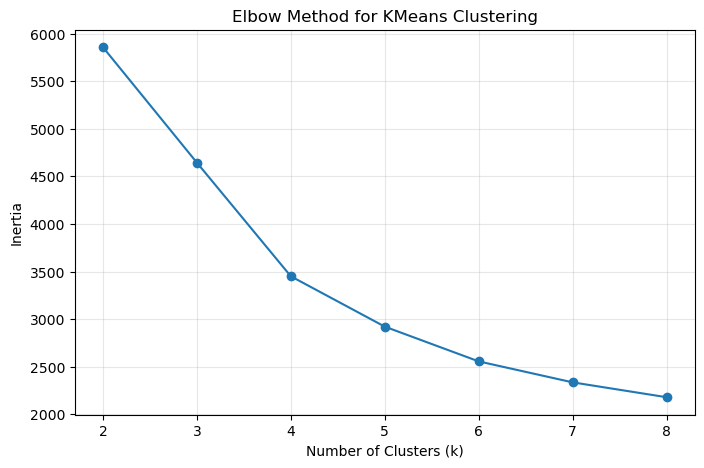

In [112]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["k"],
    results_df["inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans Clustering")

plt.grid(alpha=0.3)

plt.show()

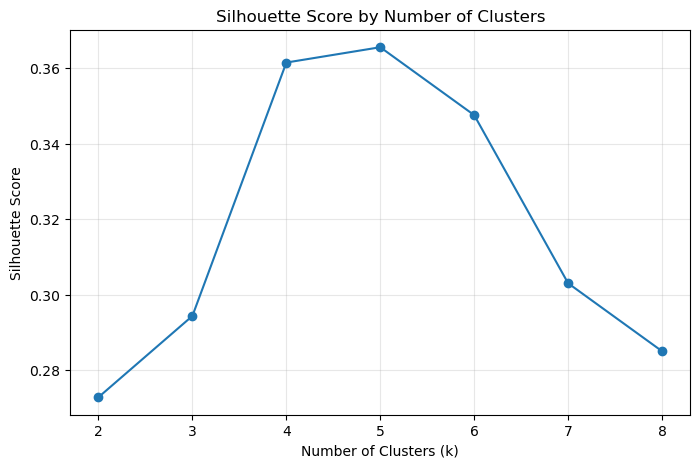

In [113]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["k"],
    results_df["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.grid(alpha=0.3)

plt.show()

In [114]:
best_row = results_df.loc[
    results_df["silhouette_score"].idxmax()
]

best_k = int(
    best_row["k"]
)

best_silhouette = float(
    best_row["silhouette_score"]
)

print("Best number of clusters:", best_k)

print(
    "Best silhouette score:",
    round(best_silhouette, 4)
)

Best number of clusters: 5
Best silhouette score: 0.3655


## Final KMeans Model

The final number of clusters is selected using the clustering diagnostics above.

The production segmentation engine should use the same:

- feature set
- feature scaling
- number of clusters
- random state
- KMeans configuration

This keeps the research notebook and production segmentation logic consistent.

In [115]:
final_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20
)

df["cluster_id"] = final_model.fit_predict(
    X_scaled
)

df[
    ["user_id", "cluster_id"]
].head()

,user_id,cluster_id
0,U0001,3
1,U0002,1
2,U0003,0
3,U0004,2
4,U0005,4


In [116]:
cluster_sizes = (
    df["cluster_id"]
    .value_counts()
    .sort_index()
    .rename("users")
)

cluster_sizes

cluster_id
0    147
1    263
2    303
3     82
4    205
Name: users, dtype: int64

In [117]:
cluster_profile = (
    df
    .groupby("cluster_id")[FEATURE_COLUMNS]
    .mean()
    .round(4)
)

cluster_profile

,avg_essential_ratio,avg_desire_ratio,avg_repayment_ratio,avg_investment_ratio,avg_expense_ratio,overspending_month_ratio,income_cv,expense_ratio_volatility
cluster_id,,,,,,,,
0,0.3412,0.1340,0.3617,0.0146,0.8982,0.0873,0.0560,0.0506
1,0.3676,0.3418,0.1059,0.0262,0.8953,0.1717,0.0528,0.0714
2,0.3309,0.1320,0.0786,0.1695,0.7505,0.0071,0.0356,0.0507
3,0.3707,0.1701,0.4363,0.0162,1.0446,0.7429,0.0548,0.0598
4,0.3669,0.1797,0.0980,0.0338,0.7330,0.0033,0.2541,0.0533


In [118]:
profile_percent = (
    cluster_profile[
        [
            "avg_essential_ratio",
            "avg_desire_ratio",
            "avg_repayment_ratio",
            "avg_investment_ratio",
            "avg_expense_ratio",
            "overspending_month_ratio",
            "income_cv",
            "expense_ratio_volatility",
        ]
    ]
    * 100
)

profile_percent.round(2)

,avg_essential_ratio,avg_desire_ratio,avg_repayment_ratio,avg_investment_ratio,avg_expense_ratio,overspending_month_ratio,income_cv,expense_ratio_volatility
cluster_id,,,,,,,,
0,34.12,13.40,36.17,1.46,89.82,8.73,5.60,5.06
1,36.76,34.18,10.59,2.62,89.53,17.17,5.28,7.14
2,33.09,13.20,7.86,16.95,75.05,0.71,3.56,5.07
3,37.07,17.01,43.63,1.62,104.46,74.29,5.48,5.98
4,36.69,17.97,9.80,3.38,73.30,0.33,25.41,5.33


In [119]:
SEGMENT_NAMES = {
    0: "Variable-Income Users",
    1: "Lifestyle-Heavy Spenders",
    2: "Consistent Savers",
    3: "Debt-Constrained Users",
    4: "Financially Stretched Users",
}


df["segment_name"] = (
    df["cluster_id"]
    .map(SEGMENT_NAMES)
)

df[
    [
        "user_id",
        "cluster_id",
        "segment_name"
    ]
].head()

,user_id,cluster_id,segment_name
0,U0001,3,Debt-Constrained Users
1,U0002,1,Lifestyle-Heavy Spenders
2,U0003,0,Variable-Income Users
3,U0004,2,Consistent Savers
4,U0005,4,Financially Stretched Users


In [120]:
segment_distribution = (
    df["segment_name"]
    .value_counts()
)

segment_distribution

segment_name
Consistent Savers              303
Lifestyle-Heavy Spenders       263
Financially Stretched Users    205
Variable-Income Users          147
Debt-Constrained Users          82
Name: count, dtype: int64

In [121]:
segment_profile = (
    df
    .groupby(
        ["cluster_id", "segment_name"]
    )[FEATURE_COLUMNS]
    .mean()
    .round(4)
    .reset_index()
)

segment_profile

,cluster_id,segment_name,avg_essential_ratio,avg_desire_ratio,avg_repayment_ratio,avg_investment_ratio,avg_expense_ratio,overspending_month_ratio,income_cv,expense_ratio_volatility
0,0,Variable-Income Users,0.3412,0.1340,0.3617,0.0146,0.8982,0.0873,0.0560,0.0506
1,1,Lifestyle-Heavy Spenders,0.3676,0.3418,0.1059,0.0262,0.8953,0.1717,0.0528,0.0714
2,2,Consistent Savers,0.3309,0.1320,0.0786,0.1695,0.7505,0.0071,0.0356,0.0507
3,3,Debt-Constrained Users,0.3707,0.1701,0.4363,0.0162,1.0446,0.7429,0.0548,0.0598
4,4,Financially Stretched Users,0.3669,0.1797,0.0980,0.0338,0.7330,0.0033,0.2541,0.0533


## Segment Interpretation

### Variable-Income Users
Characterized primarily by substantially higher income variability than the other groups. Their average spending pressure remains comparatively moderate.

### Lifestyle-Heavy Spenders
Characterized by high discretionary spending and relatively low savings allocation. Their overall expense-to-income ratio is also relatively high.

### Consistent Savers
Characterized by the highest average savings and investment allocation, comparatively controlled spending, and low overspending frequency.

### Debt-Constrained Users
Characterized by a high repayment burden. A significant portion of income is committed to repayments, reducing financial flexibility.

### Financially Stretched Users
Characterized by very high repayment burden, average outflow exceeding income, and frequent overspending months. This represents the strongest observed financial pressure among the discovered segments.

In [122]:
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster_id": df["cluster_id"],
    "segment_name": df["segment_name"],
})

print(
    "Variance explained by PC1 + PC2:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

Variance explained by PC1 + PC2: 0.5851


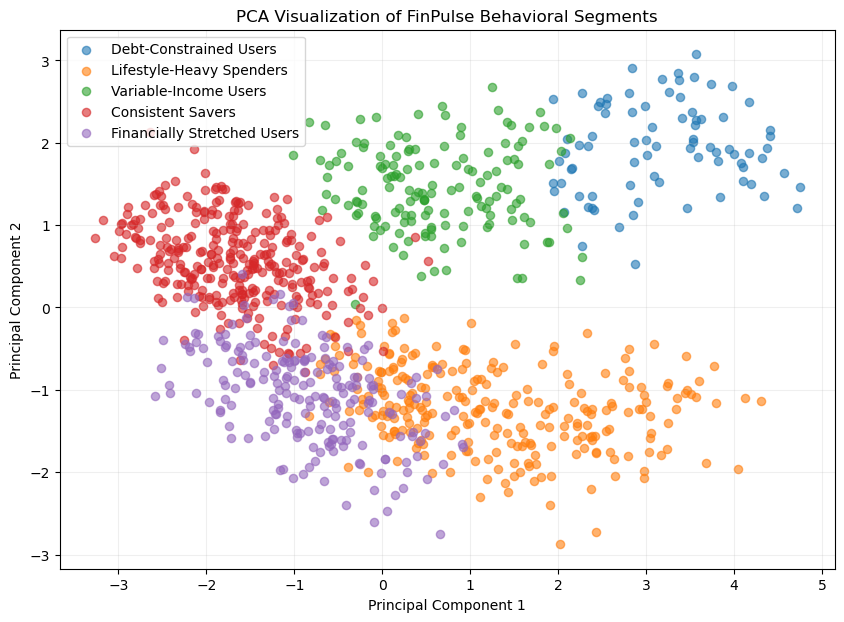

In [123]:
plt.figure(figsize=(10, 7))

for segment in pca_df["segment_name"].unique():

    segment_data = pca_df[
        pca_df["segment_name"] == segment
    ]

    plt.scatter(
        segment_data["PC1"],
        segment_data["PC2"],
        label=segment,
        alpha=0.6,
        s=35
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "PCA Visualization of FinPulse Behavioral Segments"
)

plt.legend()

plt.grid(alpha=0.2)

plt.show()

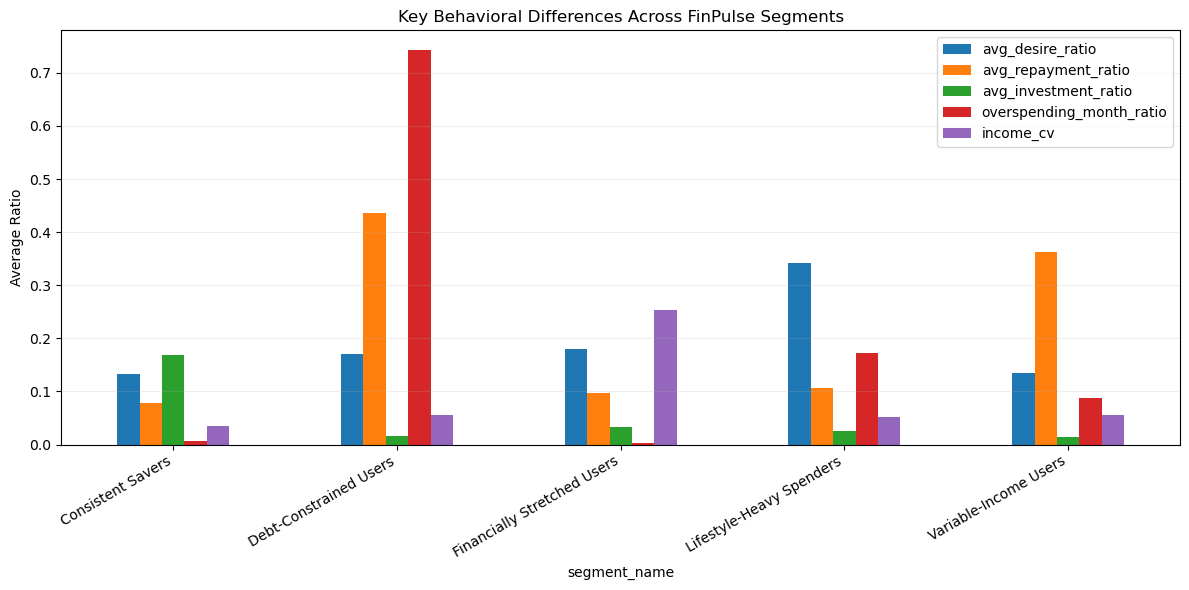

In [124]:
plot_profile = (
    df
    .groupby("segment_name")[
        [
            "avg_desire_ratio",
            "avg_repayment_ratio",
            "avg_investment_ratio",
            "overspending_month_ratio",
            "income_cv",
        ]
    ]
    .mean()
)

plot_profile.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Average Ratio")

plt.title(
    "Key Behavioral Differences Across FinPulse Segments"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()

In [125]:
with sqlite3.connect(DATABASE_FILE) as conn:
    production_segments = pd.read_sql_query(
        """
        SELECT
            user_id,
            cluster_id AS production_cluster_id,
            segment_name AS production_segment_name
        FROM user_segments
        ORDER BY user_id
        """,
        conn
    )


comparison = (
    df[
        [
            "user_id",
            "cluster_id",
            "segment_name"
        ]
    ]
    .merge(
        production_segments,
        on="user_id",
        how="left"
    )
)


comparison.head()

,user_id,cluster_id,segment_name,production_cluster_id,production_segment_name
0,U0001,3,Debt-Constrained Users,3,Debt-Constrained Users
1,U0002,1,Lifestyle-Heavy Spenders,1,Lifestyle-Heavy Spenders
2,U0003,0,Variable-Income Users,0,Variable-Income Users
3,U0004,2,Consistent Savers,2,Consistent Savers
4,U0005,4,Financially Stretched Users,4,Financially Stretched Users


In [126]:
cluster_match_rate = (
    comparison["cluster_id"]
    == comparison["production_cluster_id"]
).mean()

segment_match_rate = (
    comparison["segment_name"]
    == comparison["production_segment_name"]
).mean()


print(
    "Cluster assignment match:",
    f"{cluster_match_rate * 100:.2f}%"
)

print(
    "Segment name match:",
    f"{segment_match_rate * 100:.2f}%"
)

Cluster assignment match: 100.00%
Segment name match: 100.00%


## Conclusion

The clustering analysis identifies five distinct behavioral groups within the FinPulse user population.

The selected KMeans model uses eight standardized behavioral features derived from transaction history. The number of clusters is evaluated using both inertia and silhouette score rather than being chosen solely from predefined financial personas.

The resulting segments show clear behavioral differences across discretionary spending, repayment burden, savings allocation, overspending frequency, income stability, and overall spending pressure.

The five interpreted segments are:

1. Variable-Income Users
2. Lifestyle-Heavy Spenders
3. Consistent Savers
4. Debt-Constrained Users
5. Financially Stretched Users

These clusters are used as behavioral segmentation rather than as financial-health scores. Financial health scoring, behavioral signals, and recommendations remain separate interpretable components of the FinPulse system.

The production implementation of this analysis is contained in `scripts/segmentation_engine.py`.